# Vectors, Shapes and Norms

## Purpose

Understand how simple linear algebra vectors are represented in NumPy, why shape matters, and how to read a vector's length.

This notebook keeps the focus deliberately small:

- create a simple vector
- inspect its NumPy shape
- compare plain, row, and column shapes
- calculate its norm
- use two basic vector operations: addition and scalar multiplication

Start by importing NumPy.

In [1]:
import numpy as np

## Plotting helpers

These helpers keep the plotting setup out of the learning examples.

They are intentionally simple. The point is to make the vector diagrams readable, not to hide the maths inside clever plotting code.

In [2]:
import matplotlib.pyplot as plt


def setup_vector_plot(title=None, xlim=(-1, 6), ylim=(-1, 6), figsize=(4, 4)):
    """Create a simple 2D coordinate plane for vector diagrams."""
    fig, ax = plt.subplots(figsize=figsize)

    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)

    ax.set_xlabel("x")
    ax.set_ylabel("y")

    if title:
        ax.set_title(title)

    return fig, ax


def draw_vector(
    ax,
    vector,
    start=(0, 0),
    label=None,
    color=None,
    label_position="end",
    label_offset=(0.1, 0.1),
    linewidth=2,
    linestyle="-",
    alpha=1.0,
):
    """Draw a 2D vector as an arrow, with optional labelling."""
    start = np.array(start)
    vector = np.array(vector)
    end = start + vector

    ax.arrow(
        start[0],
        start[1],
        vector[0],
        vector[1],
        length_includes_head=True,
        head_width=0.12,
        head_length=0.18,
        linewidth=linewidth,
        linestyle=linestyle,
        color=color,
        alpha=alpha,
    )

    if label:
        if label_position == "middle":
            label_point = start + 0.5 * vector
        else:
            label_point = end

        ax.text(
            label_point[0] + label_offset[0],
            label_point[1] + label_offset[1],
            label,
            fontsize=11,
        )

## A first vector: coordinates, shape and length

A 2D vector can be drawn as an arrow from the origin to the point represented by its components.

I will use $\mathbf{v} = [3, 4]$ because it has an easy-to-check length: the 3-4-5 triangle.

The vector $[3, 4]$ starts at $(0, 0)$ and ends at $(3, 4)$.

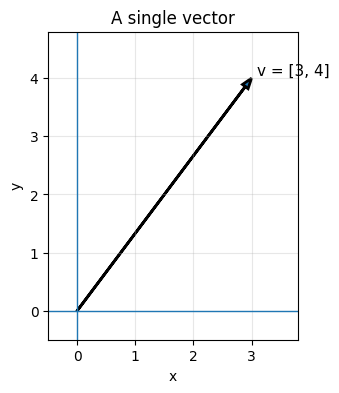

In [3]:
v = np.array([3, 4])

fig, ax = setup_vector_plot(
    title="A single vector",
    xlim=(-0.5, 3.8),
    ylim=(-0.5, 4.8),
    figsize=(4, 4),
)

draw_vector(ax, v, label="v = [3, 4]", label_offset=(0.1, 0.05))

plt.show()

The arrow ends at $(3, 4)$. Its length is the norm of the vector.

For a two-dimensional vector:

$$
\left\lVert \mathbf{v} \right\rVert =
\sqrt{x^2 + y^2}
$$

So for $\mathbf{v} = [3, 4]$:

$$
\left\lVert \mathbf{v} \right\rVert =
\sqrt{3^2 + 4^2} = 5
$$

In [4]:
print("Vector:", v)
print("Shape:", v.shape)
print("Norm:", np.linalg.norm(v))

Vector: [3 4]
Shape: (2,)
Norm: 5.0


The shape `(2,)` means this is a one-dimensional NumPy array with two elements.

It is not a row matrix or a column matrix yet.

## Why shape matters

The values can be the same while the shape is different.

This matters because later matrix operations care about whether something is shaped like a row, a column, or a plain one-dimensional array.

In [5]:
row_v = v.reshape(1, 2)
column_v = v.reshape(2, 1)

print("v:")
print(v)
print("shape:", v.shape)

print("\nrow_v:")
print(row_v)
print("shape:", row_v.shape)

print("\ncolumn_v:")
print(column_v)
print("shape:", column_v.shape)

v:
[3 4]
shape: (2,)

row_v:
[[3 4]]
shape: (1, 2)

column_v:
[[3]
 [4]]
shape: (2, 1)


The same numbers can be arranged in different ways:

- `v.shape == (2,)` means a one-dimensional NumPy array with two elements
- `row_v.shape == (1, 2)` means one row and two columns
- `column_v.shape == (2, 1)` means two rows and one column

For now, we usually want the simple one-dimensional version. Later, row and column shapes become important when we start multiplying matrices and vectors.

## Visualising vector addition

Vector addition means adding matching components.

Geometrically, this can be shown by drawing the second vector starting at the end of the first vector.

In [6]:
a = np.array([1, 4])
b = np.array([2, -2])
a_plus_b = a + b

print("Vector a:", a)
print("Vector b:", b)
print("Vector a + b:", a_plus_b)

Vector a: [1 4]
Vector b: [ 2 -2]
Vector a + b: [3 2]


The result is $[3, 2]$, because NumPy adds the first components together and the second components together:

$$
[1, 4] + [2, -2] = [3, 2]
$$

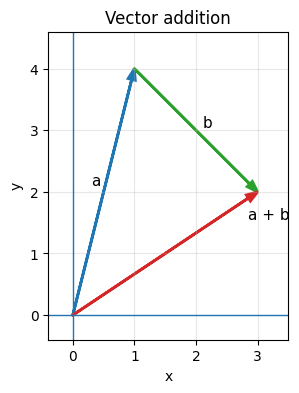

In [7]:
fig, ax = setup_vector_plot(
    title="Vector addition",
    xlim=(-0.4, 3.5),
    ylim=(-0.4, 4.6),
    figsize=(4, 4),
)

draw_vector(ax, a, label="a", color="tab:blue", label_position="middle", label_offset=(-0.2, 0.1))
draw_vector(ax, b, start=a, label="b", color="tab:green", label_position="middle", label_offset=(0.1, 0.05))
draw_vector(ax, a_plus_b, label="a + b", color="tab:red", label_offset=(-0.15, -0.45))

plt.show()

The vector $a + b$ reaches the same final point as moving first by $a$, then by $b$.

## Scalar multiplication

Multiplying a vector by a scalar changes its length while keeping the same direction, unless the scalar is negative.

In [8]:
scaled_v = 2 * v

print("v:", v)
print("2 * v:", scaled_v)
print("norm of v:", np.linalg.norm(v))
print("norm of 2 * v:", np.linalg.norm(scaled_v))

v: [3 4]
2 * v: [6 8]
norm of v: 5.0
norm of 2 * v: 10.0


The vector $[3, 4]$ becomes $[6, 8]$.

Its direction is the same, but its length has doubled from $5$ to $10$.

## Why this matters for ML

In machine learning, a vector often represents a row of features.

For example, a house could be represented as:

```text
[bedrooms, floor_area, distance_to_station]
```

A model does not see “a house” directly. It sees numbers arranged as vectors.

In [9]:
house = np.array([3, 85, 1.2])

print("House feature vector:", house)
print("Shape:", house.shape)

House feature vector: [ 3.  85.   1.2]
Shape: (3,)


This is a three-feature vector.

Later, many rows like this become a matrix.

## Summary

A vector is a small ordered collection of numbers.

In NumPy, the vector:

```python
v = np.array([3, 4])
```

has shape `(2,)`, meaning it is a one-dimensional array with two elements.

The same values can also be reshaped as a row or column:

- `(1, 2)` means one row and two columns
- `(2, 1)` means two rows and one column

The norm of a vector is its length:

$$
\left\lVert \mathbf{v} \right\rVert =
\sqrt{x^2 + y^2}
$$

For $\mathbf{v} = [3, 4]$, the norm is $5$.

Vector addition adds matching components, and scalar multiplication stretches or reverses a vector.

In machine learning, vectors often represent rows of features. Later, many feature vectors together will become a matrix.